In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

In [2]:
data = pd.read_csv('../data/final_normalized_data_for_ML.csv')
X = data.drop(columns=['HALE_Birth'])
y = data['HALE_Birth']

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 8880 samples
Testing set size: 2220 samples


In [4]:
# Initialize models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = {}

# Start the training loop
for name, model in models.items():
   
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    # Calculate performance metrics
    mse = mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    # Store results in the dictionary
    results[name] = {'MSE': mse, 'R2 Score': r2}
    print(f"{name} - Training Complete.")

Linear Regression - Training Complete.
Random Forest - Training Complete.
Gradient Boosting - Training Complete.


In [5]:
results_df = pd.DataFrame(results).T
print("\nModel Performance Comparison:")
print(results_df)

rf_model = models["Random Forest"]
importances = rf_model.feature_importances_
feature_names = X.columns


Model Performance Comparison:
                        MSE  R2 Score
Linear Regression  0.021341  0.979746
Random Forest      0.005599  0.994686
Gradient Boosting  0.028326  0.973117


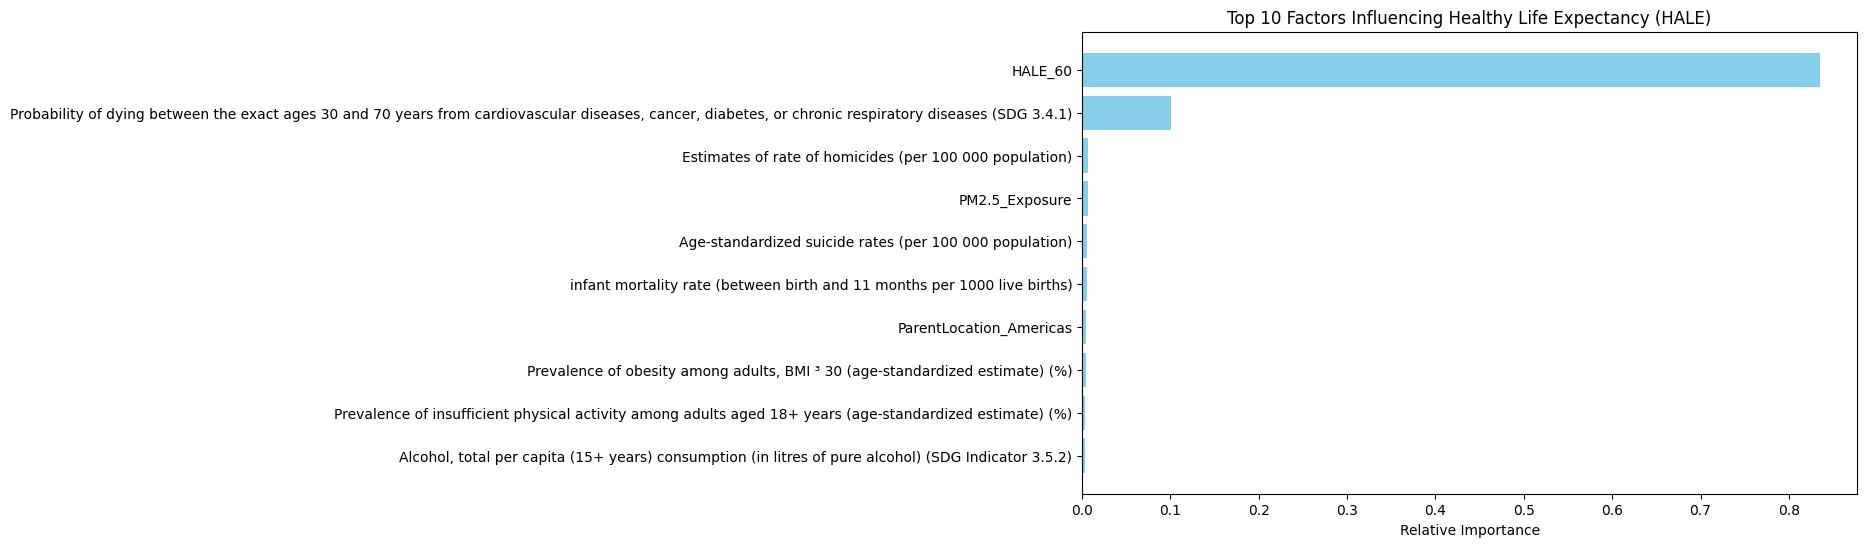

In [6]:
indices = np.argsort(importances)[-10:]

plt.figure(figsize=(10, 6))
plt.title('Top 10 Factors Influencing Healthy Life Expectancy (HALE)')
plt.barh(range(len(indices)), importances[indices], color='skyblue', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

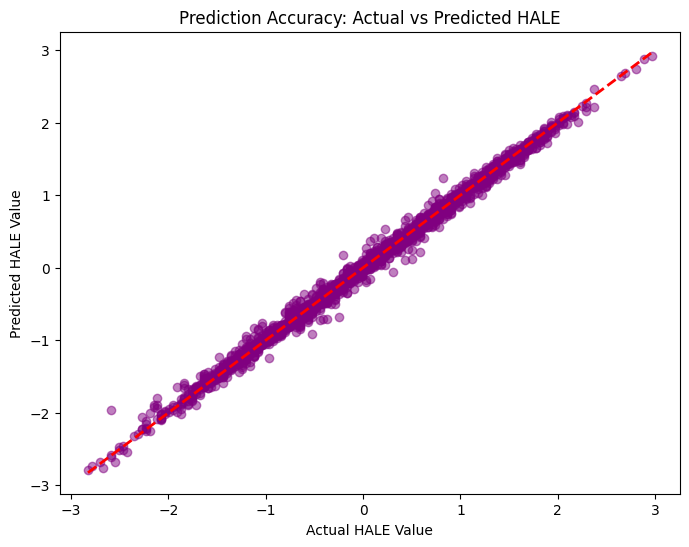

In [7]:
best_model = models["Random Forest"] # Assuming RF performs best
y_pred = best_model.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual HALE Value')
plt.ylabel('Predicted HALE Value')
plt.title('Prediction Accuracy: Actual vs Predicted HALE')
plt.show()